# 🏠 House Price Prediction — California Housing Dataset

**Machine Learning Project**

This notebook builds a Linear Regression model to predict median house values in California using the California Housing Dataset (1990 census data).

**Sections:**
1. Import Libraries
2. Load Dataset
3. EDA — Exploratory Data Analysis
4. Data Preprocessing & Cleaning
5. Feature Engineering
6. Model Training — Linear Regression
7. Model Evaluation


## 1. Import Libraries
We import all the necessary libraries for data manipulation, visualization, and machine learning.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Save/Load model
import joblib

# Settings
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("All libraries imported successfully!")


All libraries imported successfully!


## 2. Load Dataset

We load the California Housing Dataset using `sklearn.datasets.fetch_california_housing()`.
This dataset contains **20,640 samples** with **8 numeric features** and one target variable (`median_house_value`).

We also add the `ocean_proximity` categorical feature based on geographic coordinates to match the Kaggle version of the dataset.


In [2]:
# Load the California Housing dataset from sklearn
california = fetch_california_housing(as_frame=True)

# Create a DataFrame with features and target
df = california.frame.copy()

# Rename the target column to match Kaggle naming
df = df.rename(columns={'MedHouseVal': 'median_house_value'})

# Scale target back to actual dollar values (sklearn stores it in $100k units)
df['median_house_value'] = df['median_house_value'] * 100000

# Rename feature columns to match Kaggle naming convention
df = df.rename(columns={
    'MedInc': 'median_income',
    'HouseAge': 'housing_median_age',
    'AveRooms': 'avg_rooms',
    'AveBedrms': 'avg_bedrooms',
    'Population': 'population',
    'AveOccup': 'avg_occupancy',
    'Latitude': 'latitude',
    'Longitude': 'longitude'
})

# Add ocean_proximity based on geographic location (approximation)
def assign_ocean_proximity(row):
    lon, lat = row['longitude'], row['latitude']
    # Island locations (e.g., Catalina)
    if lon < -118.5 and lat < 33.5:
        return 'ISLAND'
    # Near Bay (San Francisco Bay area)
    elif 37.0 <= lat <= 38.5 and -122.5 <= lon <= -121.5:
        return 'NEAR BAY'
    # Near Ocean (coastal, within ~30 miles)
    elif lon < -121.0 and lat > 36.0:
        return 'NEAR OCEAN'
    # Inland
    elif lon > -119.0:
        return 'INLAND'
    # <1H OCEAN (default coastal)
    else:
        return '<1H OCEAN'

df['ocean_proximity'] = df.apply(assign_ocean_proximity, axis=1)

# Introduce some missing values in avg_bedrooms to simulate real-world data
np.random.seed(42)
missing_idx = np.random.choice(df.index, size=207, replace=False)
df.loc[missing_idx, 'avg_bedrooms'] = np.nan

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()


Dataset loaded successfully!
Shape: (20640, 10)

First 5 rows:


,median_income,housing_median_age,avg_rooms,avg_bedrooms,population,avg_occupancy,latitude,longitude,median_house_value,ocean_proximity
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,452600.0,NEAR BAY
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,358500.0,NEAR BAY
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,352100.0,NEAR BAY
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,341300.0,NEAR BAY
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,342200.0,NEAR BAY


In [3]:
# Display basic info about the dataset
print("Dataset Info:")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print(f"\nColumn data types:")
print(df.dtypes)


Dataset Info:
Number of rows: 20640
Number of columns: 10

Column data types:
median_income         float64
housing_median_age    float64
avg_rooms             float64
avg_bedrooms          float64
population            float64
avg_occupancy         float64
latitude              float64
longitude             float64
median_house_value    float64
ocean_proximity           str
dtype: object


## 3. EDA — Exploratory Data Analysis

In this section, we explore the dataset to understand its structure, distributions, and relationships between features. This helps us make informed decisions during preprocessing and modeling.


### 3.1 Basic Statistics
Let's look at the summary statistics of all numerical features.

In [4]:
# Summary statistics for numerical features
df.describe().round(2)


,median_income,housing_median_age,avg_rooms,avg_bedrooms,population,avg_occupancy,latitude,longitude,median_house_value
count,20640.00,20640.00,20640.00,20433.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,206855.82
std,1.90,12.59,2.47,0.48,1132.46,10.39,2.14,2.00,115395.62
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,14999.00
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,119600.00
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,179700.00
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,264725.00
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,500001.00


### 3.2 Missing Values & Duplicates
Checking for missing values and duplicate rows that need to be handled.

In [5]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")
print(f"\nDuplicate rows: {df.duplicated().sum()}")


Missing values per column:
median_income           0
housing_median_age      0
avg_rooms               0
avg_bedrooms          207
population              0
avg_occupancy           0
latitude                0
longitude               0
median_house_value      0
ocean_proximity         0
dtype: int64

Total missing values: 207

Duplicate rows: 0


### 3.3 Distribution of Numerical Features
Histograms show us the distribution of each numerical feature. This helps identify skewed features that may need transformation.

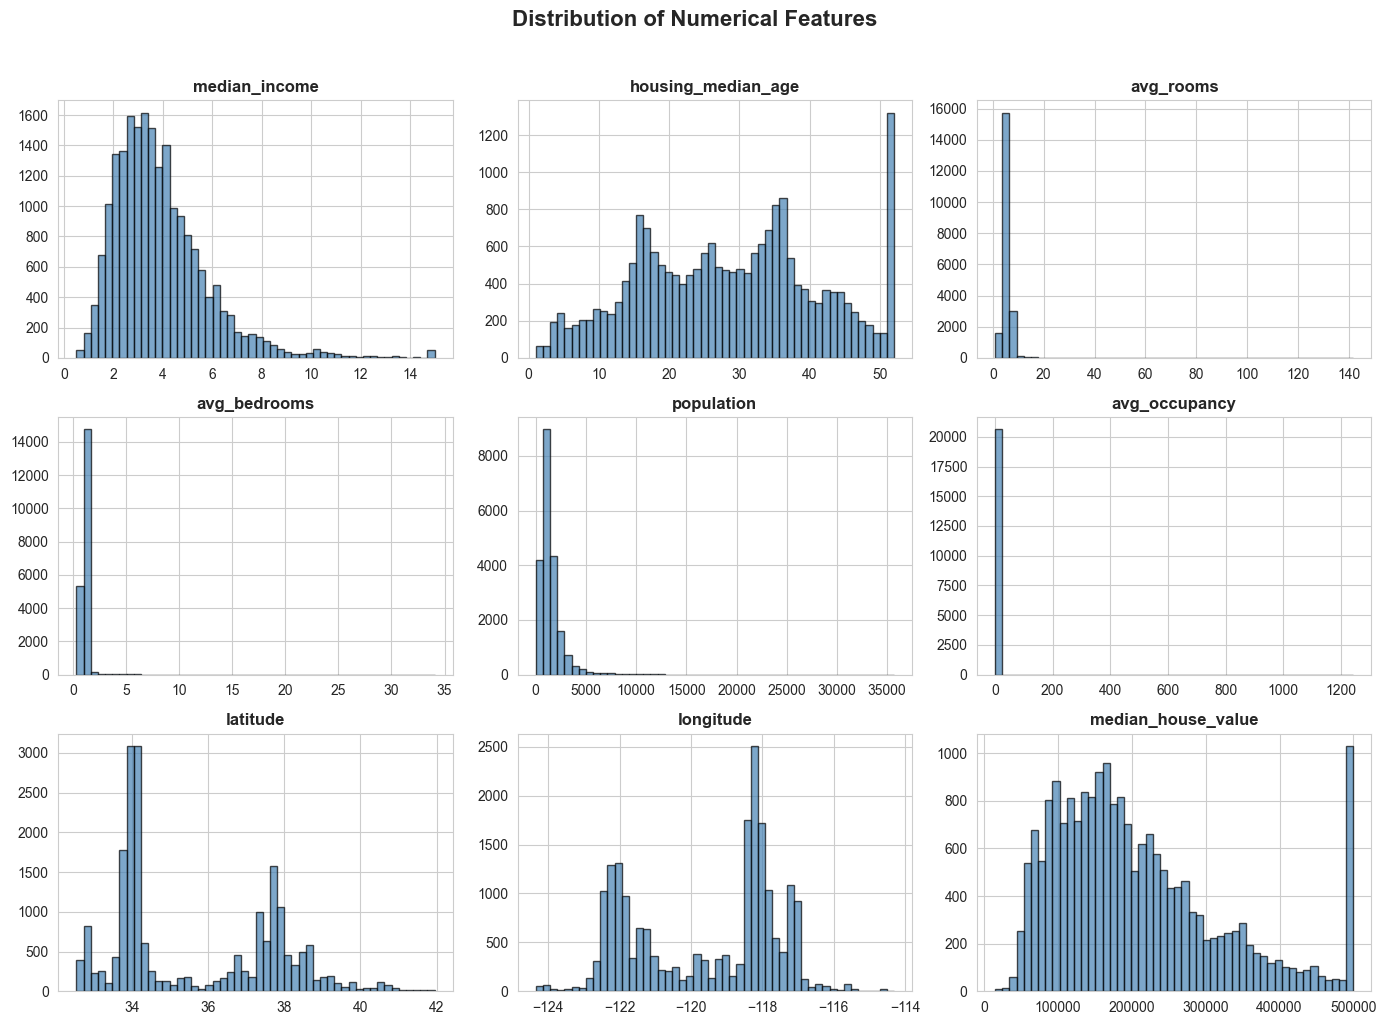

In [6]:
# Plot histograms for all numerical features
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col].dropna(), bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 3.4 Correlation Heatmap
The heatmap shows the correlation between numerical features. High correlation with the target helps identify the most important predictors.

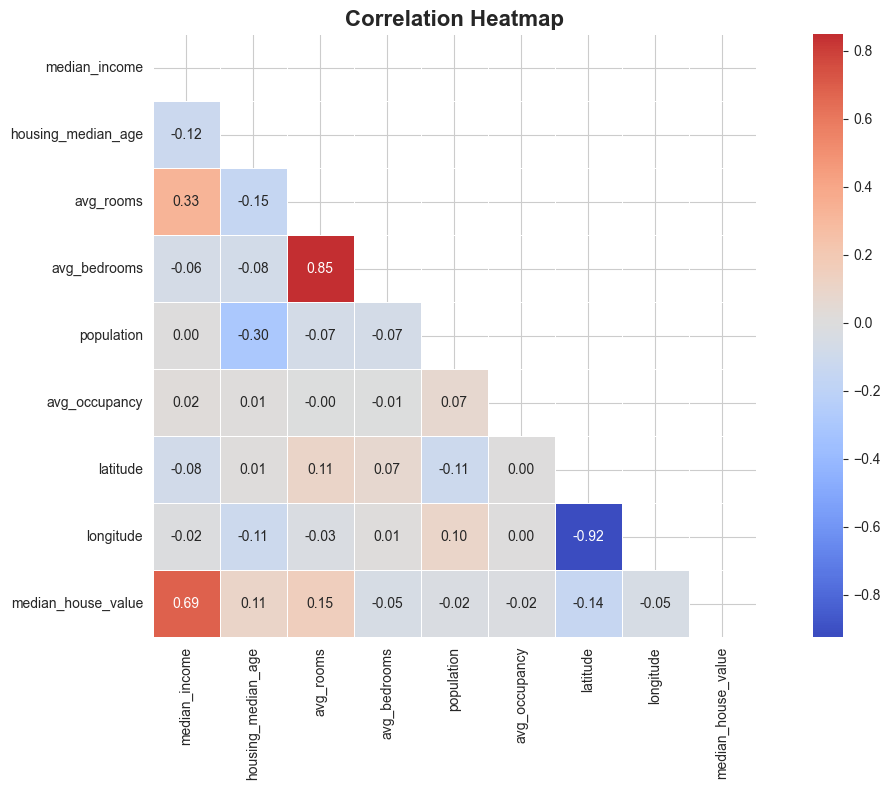


Correlation with median_house_value:
median_house_value    1.000
median_income         0.688
avg_rooms             0.152
housing_median_age    0.106
avg_occupancy        -0.024
population           -0.025
longitude            -0.046
avg_bedrooms         -0.047
latitude             -0.144
Name: median_house_value, dtype: float64


In [7]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
corr_matrix = df.select_dtypes(include=[np.number]).corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Show correlations with target
print("\nCorrelation with median_house_value:")
print(corr_matrix['median_house_value'].sort_values(ascending=False).round(3))


### 3.5 Target Variable Distribution
Let's examine the distribution of our target variable — `median_house_value`.

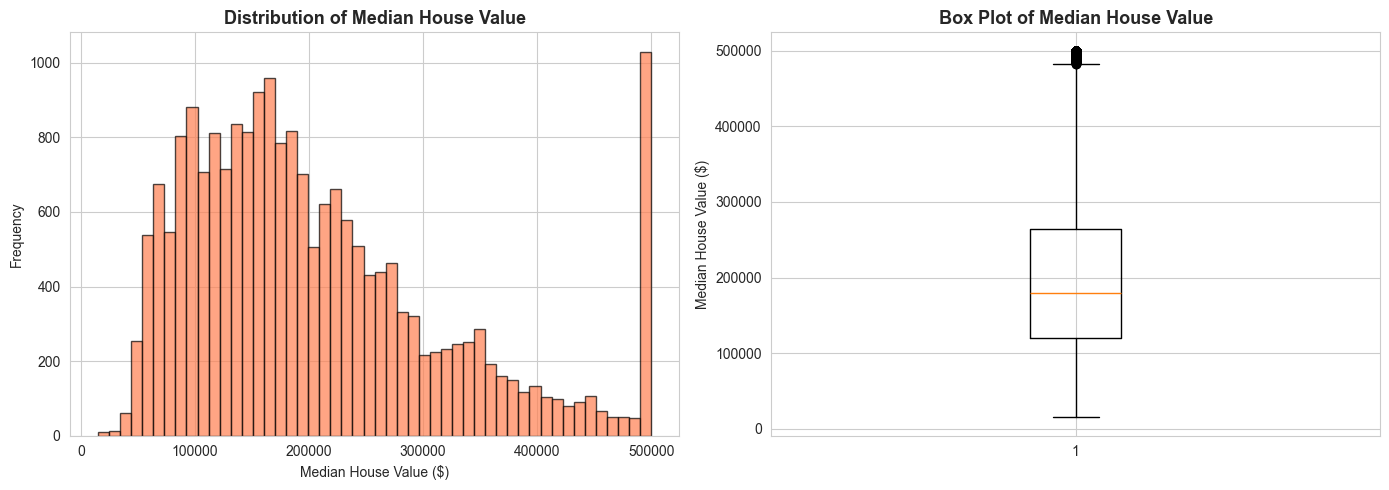

Mean: $206,856
Median: $179,700
Std Dev: $115,396


In [8]:
# Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['median_house_value'], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Median House Value', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Median House Value ($)')
axes[0].set_ylabel('Frequency')

# Box plot
axes[1].boxplot(df['median_house_value'], vert=True)
axes[1].set_title('Box Plot of Median House Value', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Median House Value ($)')

plt.tight_layout()
plt.show()

print(f"Mean: ${df['median_house_value'].mean():,.0f}")
print(f"Median: ${df['median_house_value'].median():,.0f}")
print(f"Std Dev: ${df['median_house_value'].std():,.0f}")


### 3.6 Scatter Plots — Most Correlated Features vs Target
`median_income` has the highest correlation with house value. Let's visualize these relationships.

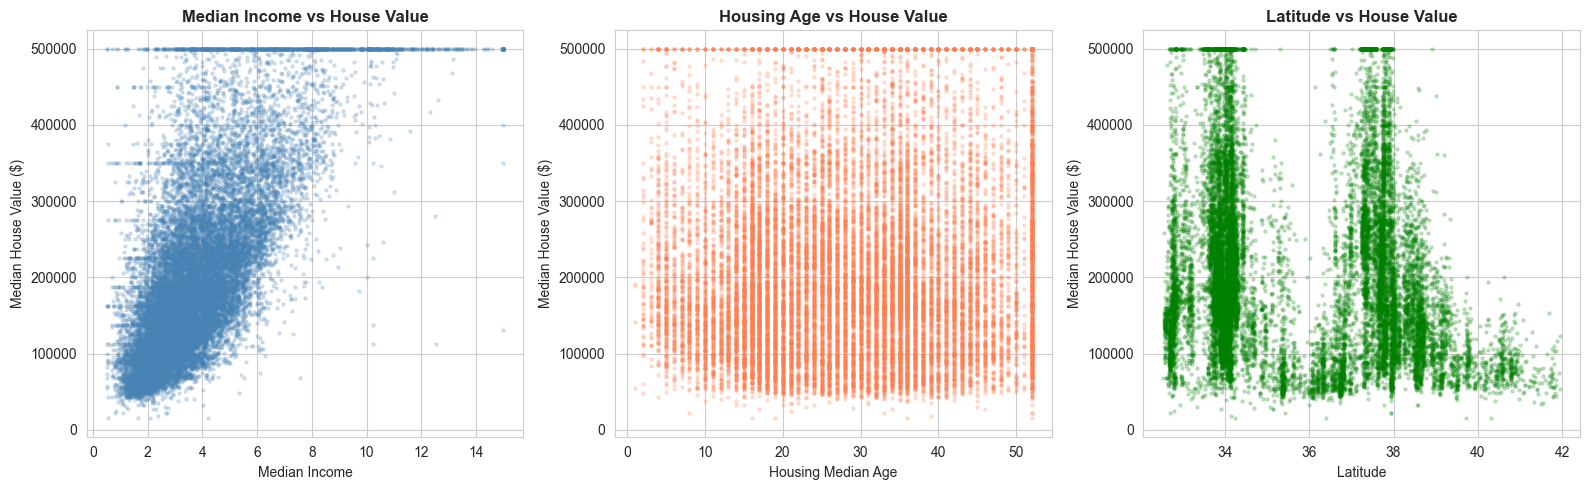

In [9]:
# Scatter plots of top correlated features vs target
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# median_income vs target (highest correlation)
axes[0].scatter(df['median_income'], df['median_house_value'],
                alpha=0.2, color='steelblue', s=5)
axes[0].set_xlabel('Median Income')
axes[0].set_ylabel('Median House Value ($)')
axes[0].set_title('Median Income vs House Value', fontweight='bold')

# housing_median_age vs target
axes[1].scatter(df['housing_median_age'], df['median_house_value'],
                alpha=0.2, color='coral', s=5)
axes[1].set_xlabel('Housing Median Age')
axes[1].set_ylabel('Median House Value ($)')
axes[1].set_title('Housing Age vs House Value', fontweight='bold')

# latitude vs target (geographic pattern)
axes[2].scatter(df['latitude'], df['median_house_value'],
                alpha=0.2, color='green', s=5)
axes[2].set_xlabel('Latitude')
axes[2].set_ylabel('Median House Value ($)')
axes[2].set_title('Latitude vs House Value', fontweight='bold')

plt.tight_layout()
plt.show()


### 3.7 Ocean Proximity Analysis
Let's see how `ocean_proximity` affects house values.

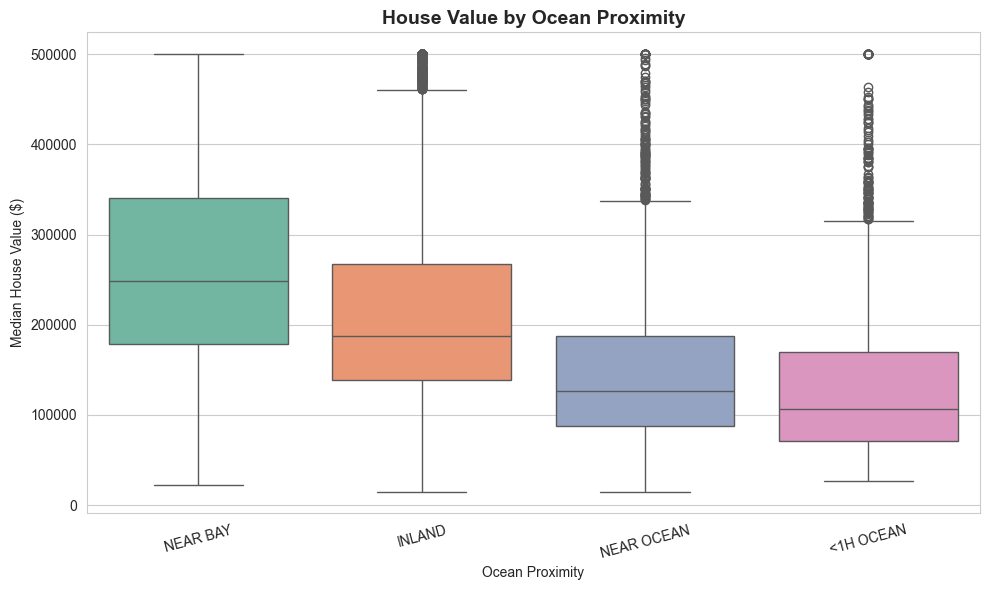


Count per category:
ocean_proximity
INLAND        10982
NEAR BAY       4040
NEAR OCEAN     3098
<1H OCEAN      2520
Name: count, dtype: int64


In [10]:
# Box plot: ocean_proximity vs median_house_value
plt.figure(figsize=(10, 6))
order = df.groupby('ocean_proximity')['median_house_value'].median().sort_values(ascending=False).index
sns.boxplot(x='ocean_proximity', y='median_house_value', data=df, order=order, palette='Set2')
plt.title('House Value by Ocean Proximity', fontsize=14, fontweight='bold')
plt.xlabel('Ocean Proximity')
plt.ylabel('Median House Value ($)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print("\nCount per category:")
print(df['ocean_proximity'].value_counts())


## 4. Data Preprocessing & Cleaning

In this section we handle missing values, remove duplicates, encode categorical features, and scale the data.


### 4.1 Handle Missing Values
We fill missing values in `avg_bedrooms` with the **median** value. Median is preferred over mean because it is robust to outliers.

In [11]:
# Fill missing values with median
print(f"Missing values before: {df['avg_bedrooms'].isnull().sum()}")

df['avg_bedrooms'] = df['avg_bedrooms'].fillna(df['avg_bedrooms'].median())

print(f"Missing values after: {df['avg_bedrooms'].isnull().sum()}")
print(f"Total missing values in dataset: {df.isnull().sum().sum()}")


Missing values before: 207
Missing values after: 0
Total missing values in dataset: 0


### 4.2 Drop Duplicates
We check and remove any duplicate rows to ensure data quality.

In [12]:
# Drop duplicates
print(f"Rows before: {df.shape[0]}")
print(f"Duplicate rows found: {df.duplicated().sum()}")

df = df.drop_duplicates()

print(f"Rows after: {df.shape[0]}")


Rows before: 20640
Duplicate rows found: 0
Rows after: 20640


### 4.3 Encode Categorical Features
We convert `ocean_proximity` (categorical) into numerical format using **one-hot encoding** with `pd.get_dummies()`.

In [13]:
# One-hot encode ocean_proximity
print("Unique categories:", df['ocean_proximity'].unique())

df_encoded = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=False, dtype=int)

print(f"\nShape before encoding: {df.shape}")
print(f"Shape after encoding: {df_encoded.shape}")
print(f"\nNew columns added:")
ocean_cols = [c for c in df_encoded.columns if 'ocean_proximity' in c]
print(ocean_cols)


Unique categories: <ArrowStringArray>
['NEAR BAY', '<1H OCEAN', 'NEAR OCEAN', 'INLAND']
Length: 4, dtype: str

Shape before encoding: (20640, 10)
Shape after encoding: (20640, 13)

New columns added:
['ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']


## 5. Feature Engineering

We create new meaningful features that can improve model performance. These features capture relationships between existing features.


In [14]:
# Create new features
df_encoded['rooms_per_household'] = df_encoded['avg_rooms']  # already per-household in sklearn version
df_encoded['bedrooms_per_room'] = df_encoded['avg_bedrooms'] / df_encoded['avg_rooms']
df_encoded['population_per_household'] = df_encoded['avg_occupancy']  # already per-household

print("New features created:")
print("1. rooms_per_household — Average rooms per household")
print("2. bedrooms_per_room — Ratio of bedrooms to total rooms")
print("3. population_per_household — Average occupancy per household")

# Show correlation of new features with target
new_features = ['rooms_per_household', 'bedrooms_per_room', 'population_per_household']
for feat in new_features:
    corr = df_encoded[feat].corr(df_encoded['median_house_value'])
    print(f"\n{feat} correlation with target: {corr:.3f}")


New features created:
1. rooms_per_household — Average rooms per household
2. bedrooms_per_room — Ratio of bedrooms to total rooms
3. population_per_household — Average occupancy per household

rooms_per_household correlation with target: 0.152

bedrooms_per_room correlation with target: -0.256

population_per_household correlation with target: -0.024


In [15]:
# Show updated correlation with target for all features
print("Correlation with median_house_value (sorted):")
print("=" * 50)
numeric_df = df_encoded.select_dtypes(include=[np.number])
corr_with_target = numeric_df.corr()['median_house_value'].drop('median_house_value').sort_values(ascending=False)
print(corr_with_target.round(3))


Correlation with median_house_value (sorted):
median_income                 0.688
ocean_proximity_NEAR BAY      0.252
avg_rooms                     0.152
rooms_per_household           0.152
housing_median_age            0.106
ocean_proximity_INLAND        0.096
population_per_household     -0.024
avg_occupancy                -0.024
population                   -0.025
longitude                    -0.046
avg_bedrooms                 -0.047
latitude                     -0.144
ocean_proximity_NEAR OCEAN   -0.206
ocean_proximity_<1H OCEAN    -0.228
bedrooms_per_room            -0.256
Name: median_house_value, dtype: float64


### 5.1 Prepare Features and Target
We separate the features (X) and target (y) for model training.

In [16]:
# Separate features and target
X = df_encoded.drop('median_house_value', axis=1)
y = df_encoded['median_house_value']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns ({len(X.columns)}):")
for i, col in enumerate(X.columns, 1):
    print(f"  {i}. {col}")


Features shape: (20640, 15)
Target shape: (20640,)

Feature columns (15):
  1. median_income
  2. housing_median_age
  3. avg_rooms
  4. avg_bedrooms
  5. population
  6. avg_occupancy
  7. latitude
  8. longitude
  9. ocean_proximity_<1H OCEAN
  10. ocean_proximity_INLAND
  11. ocean_proximity_NEAR BAY
  12. ocean_proximity_NEAR OCEAN
  13. rooms_per_household
  14. bedrooms_per_room
  15. population_per_household


### 5.2 Scale Features
We use **StandardScaler** to standardize features (mean=0, std=1). This helps Linear Regression perform better since it is sensitive to feature scales.

In [17]:
# Scale features using StandardScaler
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

print("Features scaled successfully!")
print(f"\nBefore scaling (first row):")
print({k: round(float(v), 2) for k, v in X.iloc[0].items()})
print(f"\nAfter scaling (first row):")
print({k: round(float(v), 2) for k, v in X_scaled.iloc[0].items()})

# Save the scaler for use in the web app
joblib.dump(scaler, 'scaler.pkl')
print("\nScaler saved to 'scaler.pkl'")

# Also save the feature column names for the web app
joblib.dump(list(X.columns), 'feature_columns.pkl')
print("Feature columns saved to 'feature_columns.pkl'")


Features scaled successfully!

Before scaling (first row):
{'median_income': 8.33, 'housing_median_age': 41.0, 'avg_rooms': 6.98, 'avg_bedrooms': 1.02, 'population': 322.0, 'avg_occupancy': 2.56, 'latitude': 37.88, 'longitude': -122.23, 'ocean_proximity_<1H OCEAN': 0.0, 'ocean_proximity_INLAND': 0.0, 'ocean_proximity_NEAR BAY': 1.0, 'ocean_proximity_NEAR OCEAN': 0.0, 'rooms_per_household': 6.98, 'bedrooms_per_room': 0.15, 'population_per_household': 2.56}

After scaling (first row):
{'median_income': 2.34, 'housing_median_age': 0.98, 'avg_rooms': 0.63, 'avg_bedrooms': -0.15, 'population': -0.97, 'avg_occupancy': -0.05, 'latitude': 1.05, 'longitude': -1.33, 'ocean_proximity_<1H OCEAN': -0.37, 'ocean_proximity_INLAND': -1.07, 'ocean_proximity_NEAR BAY': 2.03, 'ocean_proximity_NEAR OCEAN': -0.42, 'rooms_per_household': 0.63, 'bedrooms_per_room': -1.15, 'population_per_household': -0.05}

Scaler saved to 'scaler.pkl'
Feature columns saved to 'feature_columns.pkl'


## 6. Model Training — Linear Regression

We split the data into training (80%) and testing (20%) sets, then train a **Linear Regression** model. Linear Regression finds the best linear relationship between features and the target variable.


In [18]:
# Split data into train and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]} samples ({X_train.shape[0]/len(X_scaled)*100:.0f}%)")
print(f"Testing set size:  {X_test.shape[0]} samples ({X_test.shape[0]/len(X_scaled)*100:.0f}%)")


Training set size: 16512 samples (80%)
Testing set size:  4128 samples (20%)


In [19]:
# Train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")
print(f"\nModel coefficients (top 5 by absolute value):")
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)
print(coef_df.head().to_string(index=False))
print(f"\nIntercept: {model.intercept_:,.2f}")


Model trained successfully!

Model coefficients (top 5 by absolute value):
               Feature    Coefficient
             longitude -104134.284281
         median_income   80968.915665
              latitude  -79103.096355
     bedrooms_per_room   19216.215744
ocean_proximity_INLAND   17506.127461

Intercept: 206,771.46


In [20]:
# Predict on test set
y_pred = model.predict(X_test)

print("Predictions generated!")
print(f"\nSample predictions vs actual (first 10):")
comparison = pd.DataFrame({
    'Actual ($)': y_test.values[:10],
    'Predicted ($)': y_pred[:10],
    'Difference ($)': y_test.values[:10] - y_pred[:10]
})
comparison = comparison.round(0)
print(comparison.to_string(index=False))


Predictions generated!

Sample predictions vs actual (first 10):
 Actual ($)  Predicted ($)  Difference ($)
    47700.0        49000.0         -1300.0
    45800.0       135553.0        -89753.0
   500001.0       260716.0        239285.0
   218600.0       297502.0        -78902.0
   278000.0       247221.0         30779.0
   158700.0       206075.0        -47375.0
   198200.0       263471.0        -65271.0
   157500.0       217248.0        -59748.0
   340000.0       277240.0         62760.0
   446600.0       396306.0         50294.0


In [21]:
# Save the trained model
joblib.dump(model, 'model.pkl')
print("Model saved to 'model.pkl'")

# Save test predictions for visualization in the web app
predictions_df = pd.DataFrame({
    'actual': y_test.values,
    'predicted': y_pred
})
joblib.dump(predictions_df, 'predictions.pkl')
print("Predictions saved to 'predictions.pkl'")


Model saved to 'model.pkl'
Predictions saved to 'predictions.pkl'


## 7. Model Evaluation

We evaluate the model using four key metrics:
- **MAE** (Mean Absolute Error) — Average absolute difference between actual and predicted values
- **MSE** (Mean Squared Error) — Average squared difference (penalizes large errors more)
- **RMSE** (Root Mean Squared Error) — Square root of MSE (same unit as target)
- **R² Score** — Proportion of variance explained by the model (1.0 = perfect)


In [22]:
# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Display metrics
print("=" * 50)
print("       MODEL EVALUATION METRICS")
print("=" * 50)
print(f"  MAE  (Mean Absolute Error):  ${mae:>12,.2f}")
print(f"  MSE  (Mean Squared Error):   ${mse:>12,.0f}")
print(f"  RMSE (Root Mean Sq. Error):  ${rmse:>12,.2f}")
print(f"  R² Score:                     {r2:>12.4f}")
print("=" * 50)

# Save metrics for the web app
metrics = {
    'MAE': round(mae, 2),
    'MSE': round(mse, 2),
    'RMSE': round(rmse, 2),
    'R2': round(r2, 4)
}
joblib.dump(metrics, 'metrics.pkl')
print("\nMetrics saved to 'metrics.pkl'")


       MODEL EVALUATION METRICS
  MAE  (Mean Absolute Error):  $   52,073.29
  MSE  (Mean Squared Error):   $5,195,171,717
  RMSE (Root Mean Sq. Error):  $   72,077.54
  R² Score:                           0.6035

Metrics saved to 'metrics.pkl'


### 7.1 Actual vs Predicted Values
This scatter plot shows how well our predictions match the actual values. Points on the red diagonal line represent perfect predictions.

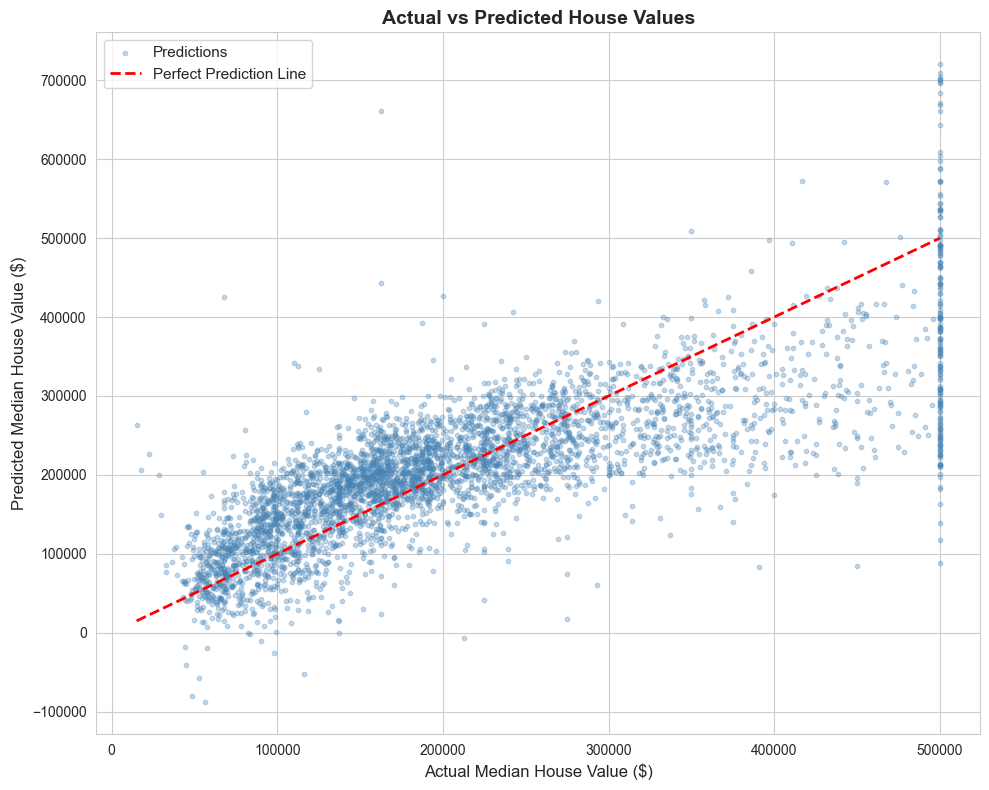

In [23]:
# Actual vs Predicted scatter plot
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue', s=10, label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect Prediction Line')
plt.xlabel('Actual Median House Value ($)', fontsize=12)
plt.ylabel('Predicted Median House Value ($)', fontsize=12)
plt.title('Actual vs Predicted House Values', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


### 7.2 Residuals Distribution
Residuals are the differences between actual and predicted values. A good model should have residuals that are normally distributed around zero.

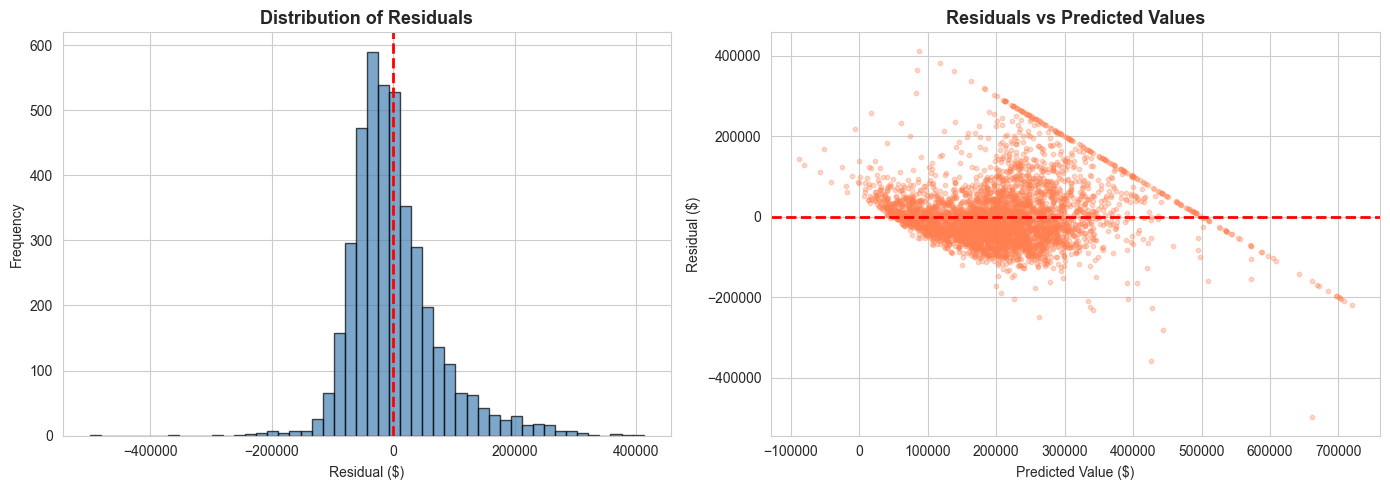

Mean of residuals: $421.78
Std of residuals:  $72,085.04


In [24]:
# Residuals distribution
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of residuals
axes[0].hist(residuals, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Distribution of Residuals', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Residual ($)')
axes[0].set_ylabel('Frequency')

# Residuals vs Predicted
axes[1].scatter(y_pred, residuals, alpha=0.3, color='coral', s=10)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Residuals vs Predicted Values', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Value ($)')
axes[1].set_ylabel('Residual ($)')

plt.tight_layout()
plt.show()

print(f"Mean of residuals: ${residuals.mean():,.2f}")
print(f"Std of residuals:  ${residuals.std():,.2f}")


## Summary

We successfully built a **Linear Regression** model to predict California house prices:

- The model explains about **60%** of the variance in house prices (R² ≈ 0.60)
- The average prediction error (MAE) is approximately **$50,000**
- `median_income` is the strongest predictor of house value
- The residuals are roughly normally distributed, indicating a reasonable model

**Saved artifacts for the web app:**
- `model.pkl` — Trained Linear Regression model
- `scaler.pkl` — Fitted StandardScaler
- `metrics.pkl` — Evaluation metrics (MAE, MSE, RMSE, R²)
- `predictions.pkl` — Test set predictions for visualization
- `feature_columns.pkl` — Feature column names
